# 09 — ML results: central test & final strategy (S4 deliverables)

Paper-level figures + tables. Central test: **do the RMT spectral features add predictive power
beyond the VIX?** (the result to polish, more than the Sharpe).
Dataviz rules: a single axis per panel, colour per entity in fixed order, thin marks.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"
FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
TAB = ROOT / "results" / "tables"; TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.22, "axes.axisbelow": True,
                     "figure.dpi": 150})
INK, MUTED = "#2b2b2b", "#767676"
# colour PER ENTITY (fixed order, never recycled)
COL = {"v0": "#767676", "v1": "#eda100", "v1rmt": "#4a3aa7", "ml": "#eb6834",
       "A_vix": "#767676", "B_spectral": "#2a78d6", "Full": "#eb6834"}
CRISES = [("1998-08-01", "1998-10-15"), ("2002-06-01", "2002-10-15"),
          ("2008-09-01", "2009-03-31"), ("2011-08-01", "2011-10-15"),
          ("2018-02-01", "2018-02-28"), ("2020-02-20", "2020-04-30"),
          ("2022-01-01", "2022-10-15")]
def shade(ax):
    for a, b in CRISES:
        ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color="#e34948", alpha=0.07, lw=0)

summary = json.load(open(P / "ml_summary.json"))
tab = pd.read_parquet(P / "ml_metrics_table.parquet")
pred = pd.read_parquet(P / "ml_predictions.parquet"); pred["date"] = pd.to_datetime(pred["date"])
print("loaded. strategies:", list(tab.index))

loaded. strategies: ['v0', 'v0_net', 'v1', 'v1_net', 'v1rmt', 'v1rmt_net', 'ml_A_vix_gross', 'ml_A_vix_net', 'ml_B_spectral_gross', 'ml_B_spectral_net', 'ml_Full_gross', 'ml_Full_net']


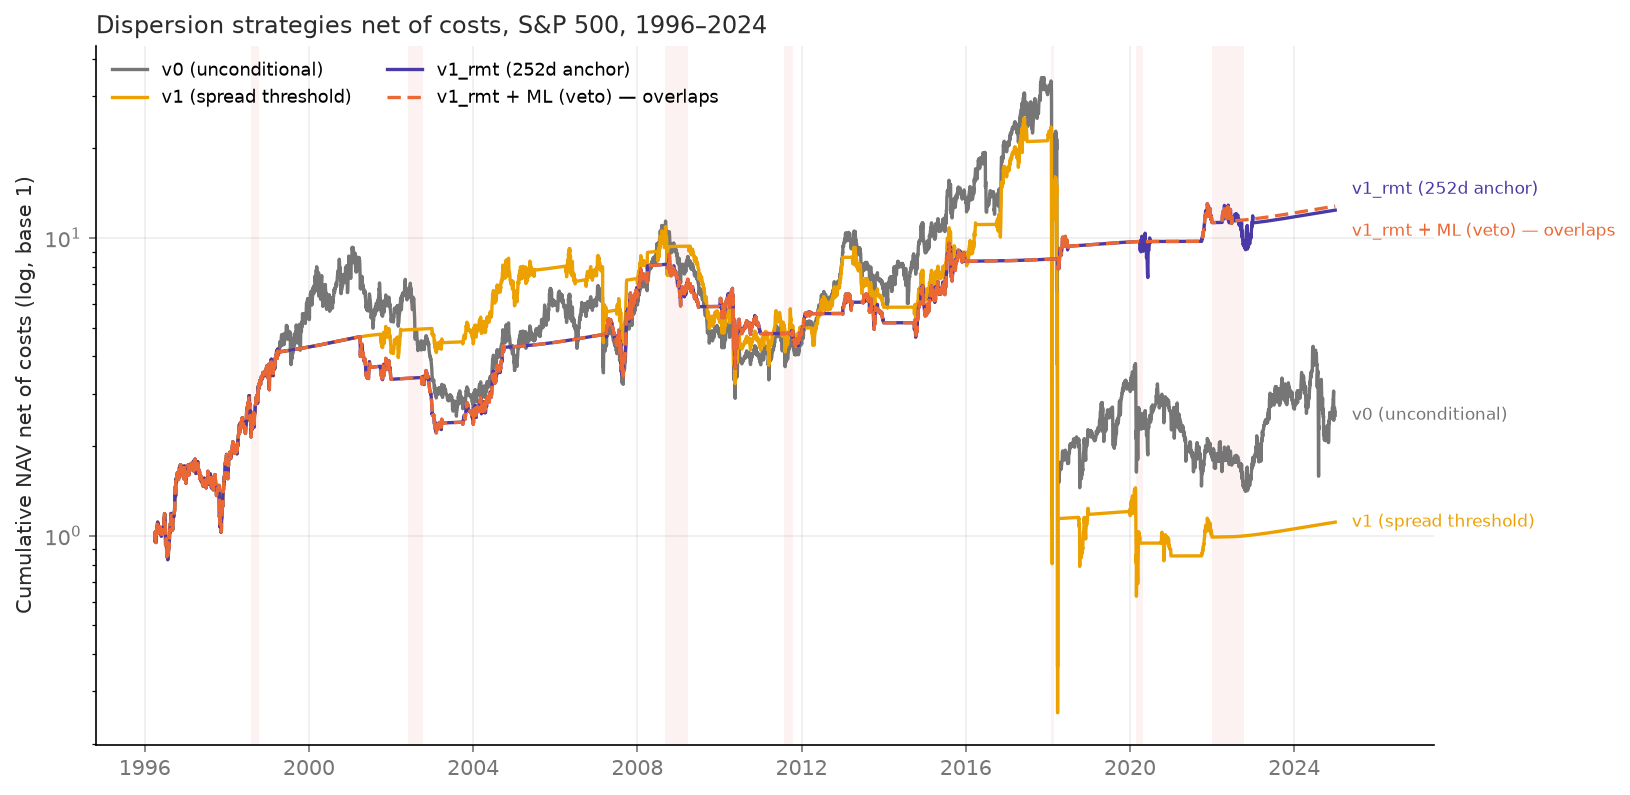

In [2]:
# FIG 1 — Cumulative net NAV, 4 strategies (log), shaded crises
fig, ax = plt.subplots(figsize=(11, 5.4))
series = [("v0_net", "v0 (unconditional)", COL["v0"], "-", 0),
          ("v1_net", "v1 (spread threshold)", COL["v1"], "-", 0),
          ("v1rmt_net", "v1_rmt (252d anchor)", COL["v1rmt"], "-", 10),
          ("ml_Full_net", "v1_rmt + ML (veto) — overlaps", COL["ml"], (0, (4, 2)), -12)]
shade(ax)
for tag, lab, c, ls, dy in series:
    d = pd.read_parquet(P / f"backtest_{tag}_daily.parquet"); d["date"] = pd.to_datetime(d["date"])
    nav = (1 + d["ret"].astype(float)).cumprod()
    ax.plot(d["date"], nav, color=c, lw=1.6, ls=ls, label=lab)
    ax.annotate(lab, xy=(d["date"].iloc[-1], nav.iloc[-1]), xytext=(8, dy),
                textcoords="offset points", va="center", fontsize=8, color=c)
ax.set_yscale("log"); ax.set_ylabel("Cumulative NAV net of costs (log, base 1)", color=INK)
ax.set_xlim(right=pd.Timestamp("2027-06-01"))
ax.set_title("Dispersion strategies net of costs, S&P 500, 1996–2024",
             loc="left", fontsize=11.5, color=INK)
ax.legend(loc="upper left", frameon=False, fontsize=8.5, ncol=2)
ax.tick_params(colors=MUTED); ax.xaxis.set_major_locator(mdates.YearLocator(4))
fig.tight_layout(); fig.savefig(FIG / "fig_ml_nav.png", bbox_inches="tight"); plt.show()

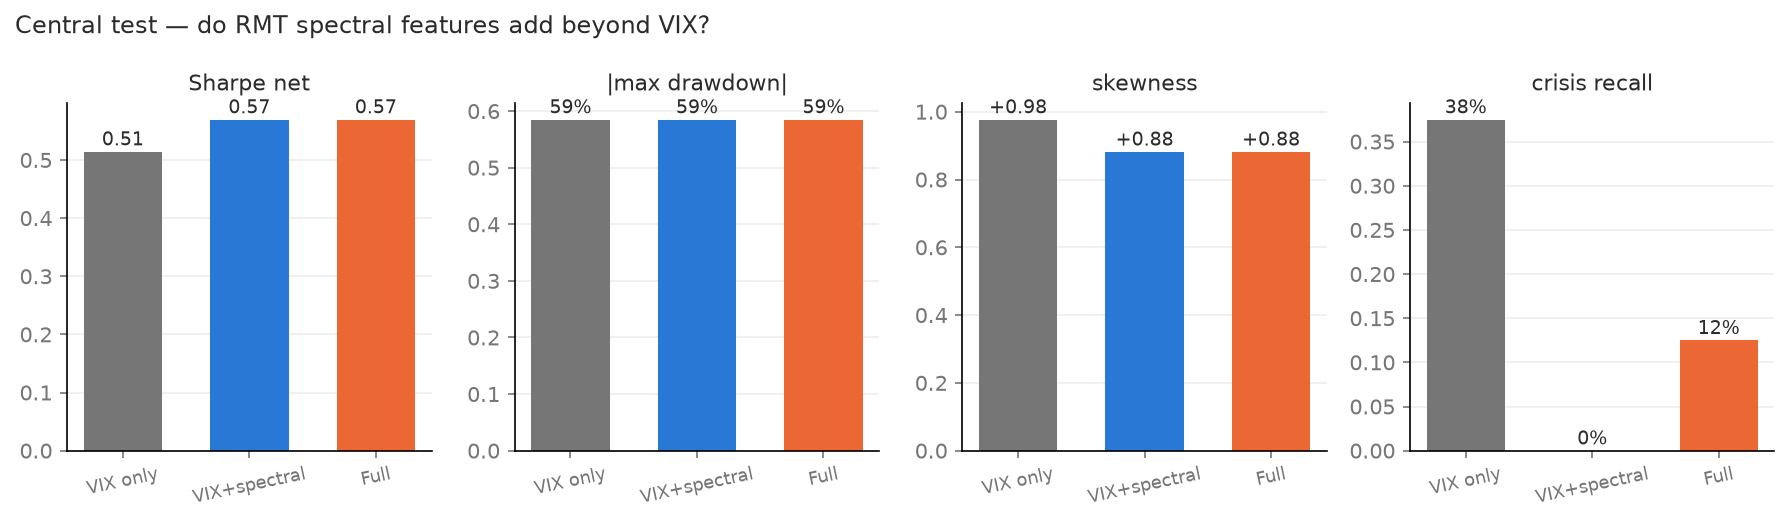

In [3]:
# FIG 2 — CENTRAL TEST: VIX only vs VIX+spectral vs Full (small multiples, 1 axis each)
arms = ["A_vix", "B_spectral", "Full"]
armlab = {"A_vix": "VIX only", "B_spectral": "VIX+spectral", "Full": "Full"}
def m(tag): return tab.loc[f"ml_{tag}_net"]
panels = [("Sharpe net", [m(a)["sharpe"] for a in arms], "{:.2f}"),
          ("|max drawdown|", [abs(m(a)["maxDD"]) for a in arms], "{:.0%}"),
          ("skewness", [m(a)["skew"] for a in arms], "{:+.2f}"),
          ("crisis recall", [summary[a]["pred"].get("recall_crisis", np.nan) for a in arms], "{:.0%}")]
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, (title, vals, fmt) in zip(axes, panels):
    bars = ax.bar(range(3), vals, color=[COL[a] for a in arms], width=0.62)
    ax.set_title(title, fontsize=10.5, color=INK)
    ax.set_xticks(range(3)); ax.set_xticklabels([armlab[a] for a in arms], fontsize=8.5, rotation=12)
    ax.tick_params(colors=MUTED); ax.grid(axis="x", alpha=0)
    for b, v in zip(bars, vals):
        if np.isfinite(v):
            ax.annotate(fmt.format(v), xy=(b.get_x()+b.get_width()/2, b.get_height()),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9, color=INK)
fig.suptitle("Central test — do RMT spectral features add beyond VIX?",
             x=0.01, ha="left", fontsize=11.5, color=INK)
fig.tight_layout(); fig.savefig(FIG / "fig_central_test.png", bbox_inches="tight"); plt.show()

/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_20923/4176461415.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(FIG / "fig_regime_timeline.png", bbox_inches="tight"); plt.show()


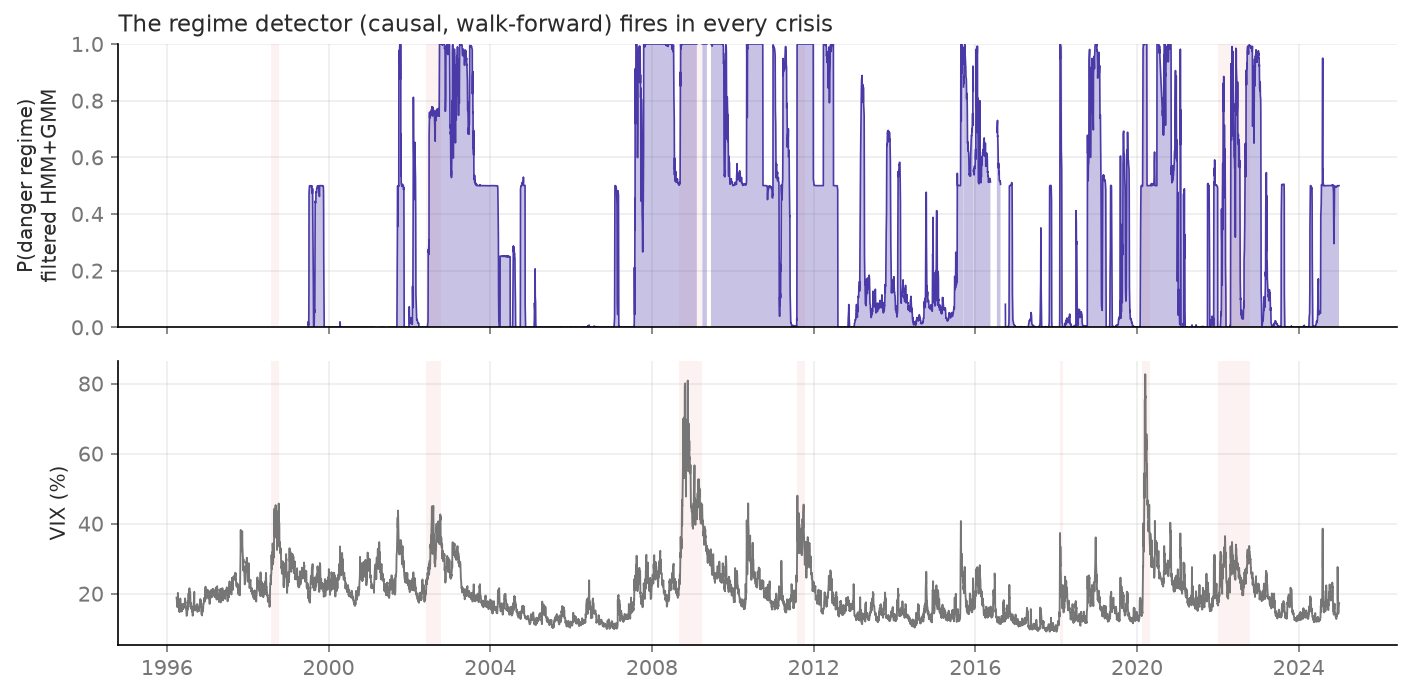

In [4]:
# FIG 3 — Regime detector: danger prob (top) + VIX (bottom), stacked panels (NO twin axis)
ml = pd.read_parquet(P / "ml_dataset.parquet"); ml["date"] = pd.to_datetime(ml["date"])
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1], "hspace": 0.12})
shade(a1); shade(a2)
a1.fill_between(ml["date"], 0, ml["f_regime"], color="#4a3aa7", alpha=0.30, lw=0)
a1.plot(ml["date"], ml["f_regime"], color="#4a3aa7", lw=0.8)
a1.set_ylabel("P(danger regime)\nfiltered HMM+GMM", color=INK, fontsize=9.5); a1.set_ylim(0, 1)
a1.set_title("The regime detector (causal, walk-forward) fires in every crisis",
             loc="left", fontsize=11, color=INK)
a2.plot(ml["date"], ml["f_vix"] * 100, color=MUTED, lw=0.9)
a2.set_ylabel("VIX (%)", color=INK, fontsize=9.5)
for a in (a1, a2):
    a.tick_params(colors=MUTED)
a2.xaxis.set_major_locator(mdates.YearLocator(4))
fig.tight_layout(); fig.savefig(FIG / "fig_regime_timeline.png", bbox_inches="tight"); plt.show()

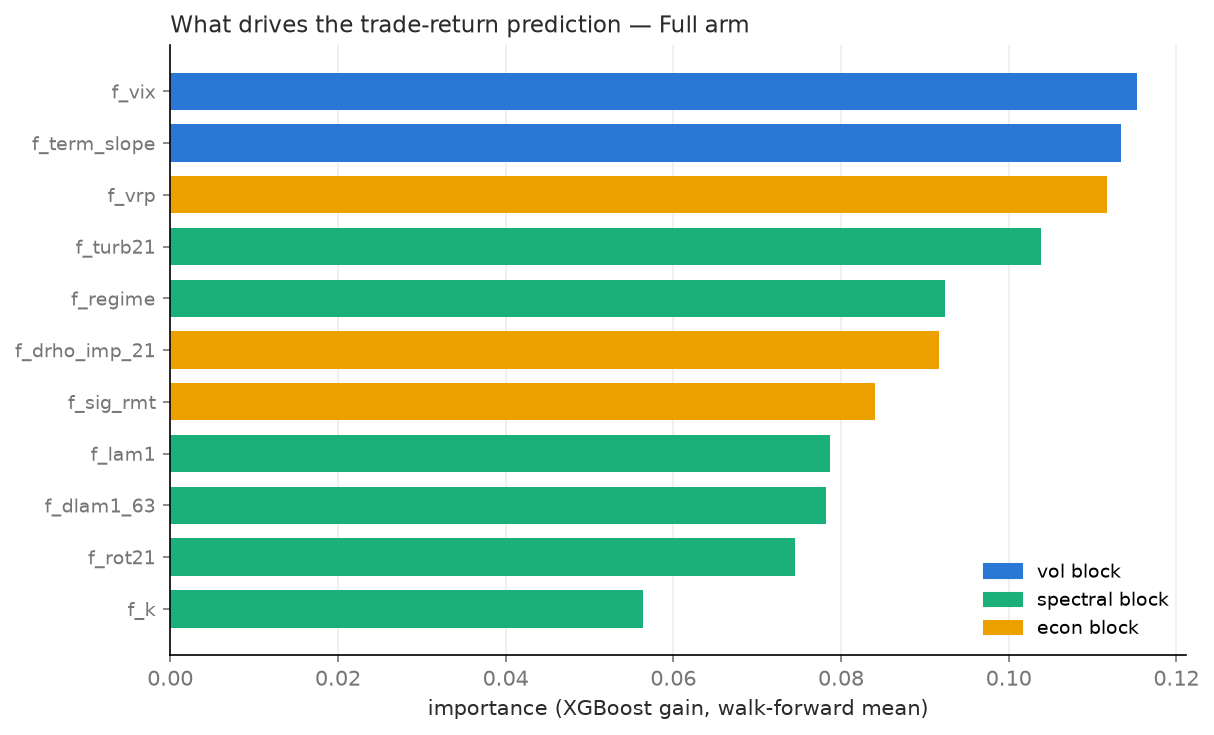

In [5]:
# FIG 4 — Feature importance (XGBoost gain, Full arm), colour per block
BLOCK = {"f_vix": "vol", "f_term_slope": "vol", "f_lam1": "spectral", "f_dlam1_63": "spectral",
         "f_turb21": "spectral", "f_k": "spectral", "f_rot21": "spectral", "f_regime": "spectral",
         "f_vrp": "econ", "f_drho_imp_21": "econ", "f_sig_rmt": "econ"}
BCOL = {"vol": "#2a78d6", "spectral": "#1baf7a", "econ": "#eda100"}
imp = pd.Series(summary["Full"]["importance"]).sort_values()
fig, ax = plt.subplots(figsize=(8.2, 5))
ax.barh(range(len(imp)), imp.values, color=[BCOL[BLOCK[f]] for f in imp.index], height=0.72)
ax.set_yticks(range(len(imp))); ax.set_yticklabels(imp.index, fontsize=9)
ax.set_xlabel("importance (XGBoost gain, walk-forward mean)", color=INK)
ax.set_title("What drives the trade-return prediction — Full arm", loc="left",
             fontsize=11, color=INK)
handles = [plt.Rectangle((0, 0), 1, 1, color=BCOL[b]) for b in BCOL]
ax.legend(handles, [f"{b} block" for b in BCOL], frameon=False, fontsize=9, loc="lower right")
ax.tick_params(colors=MUTED); ax.grid(axis="y", alpha=0)
fig.tight_layout(); fig.savefig(FIG / "fig_feature_importance.png", bbox_inches="tight"); plt.show()

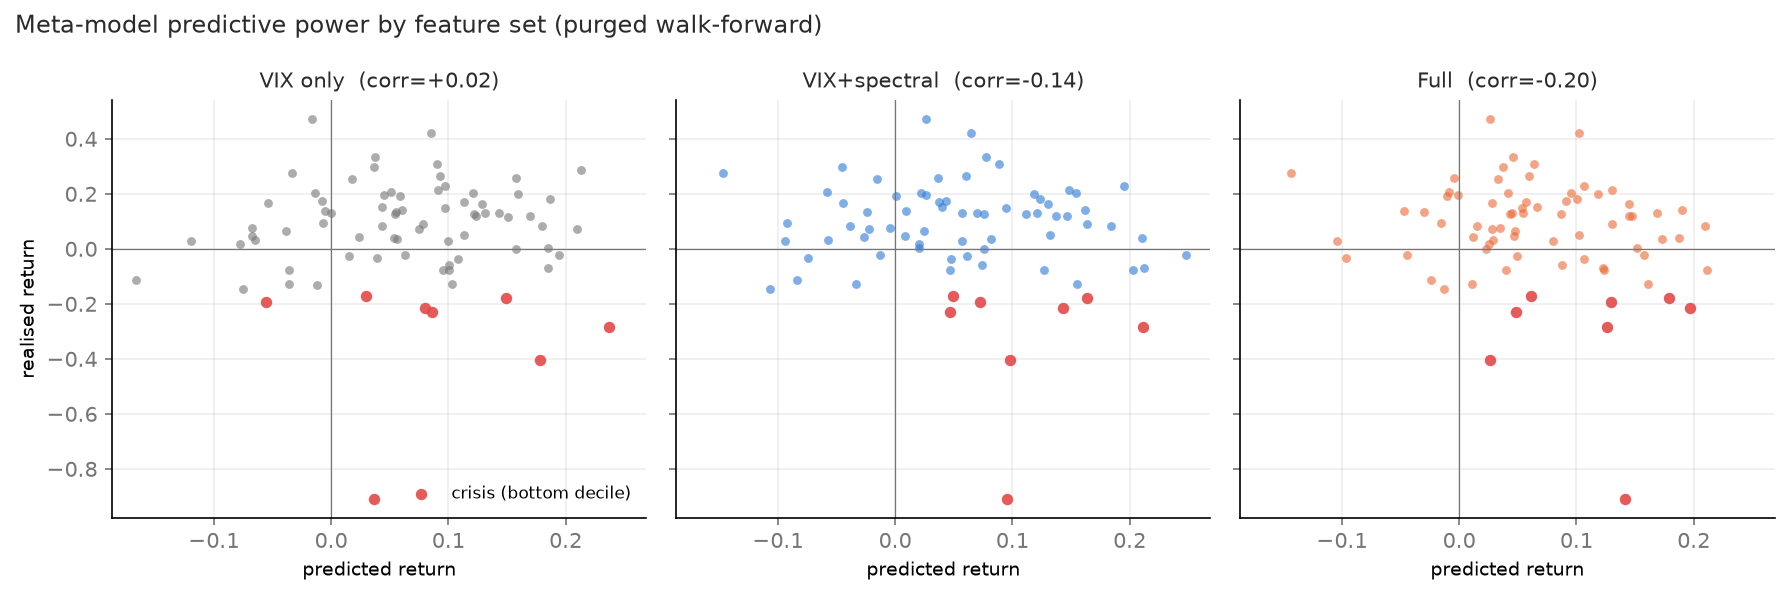

In [6]:
# FIG 5 — Predicted vs realised (quarterly return), per arm, crises in red
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
y = pred["y"].to_numpy()
crisis = y <= np.nanquantile(y, 0.10)
for ax, arm in zip(axes, arms):
    yh = pred[f"yhat_{arm}"].to_numpy()
    ok = np.isfinite(yh) & np.isfinite(y)
    r = np.corrcoef(yh[ok], y[ok])[0, 1] if ok.sum() > 3 else np.nan
    ax.axhline(0, color=MUTED, lw=0.6); ax.axvline(0, color=MUTED, lw=0.6)
    ax.scatter(yh[ok & ~crisis], y[ok & ~crisis], s=18, color=COL[arm], alpha=0.6, lw=0)
    ax.scatter(yh[ok & crisis], y[ok & crisis], s=30, color="#e34948", alpha=0.9, lw=0, label="crisis (bottom decile)")
    ax.set_title(f"{armlab[arm]}  (corr={r:+.2f})", fontsize=10, color=INK)
    ax.set_xlabel("predicted return", fontsize=9); ax.tick_params(colors=MUTED)
axes[0].set_ylabel("realised return", fontsize=9)
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Meta-model predictive power by feature set (purged walk-forward)",
             x=0.01, ha="left", fontsize=11.5, color=INK)
fig.tight_layout(); fig.savefig(FIG / "fig_pred_scatter.png", bbox_inches="tight"); plt.show()

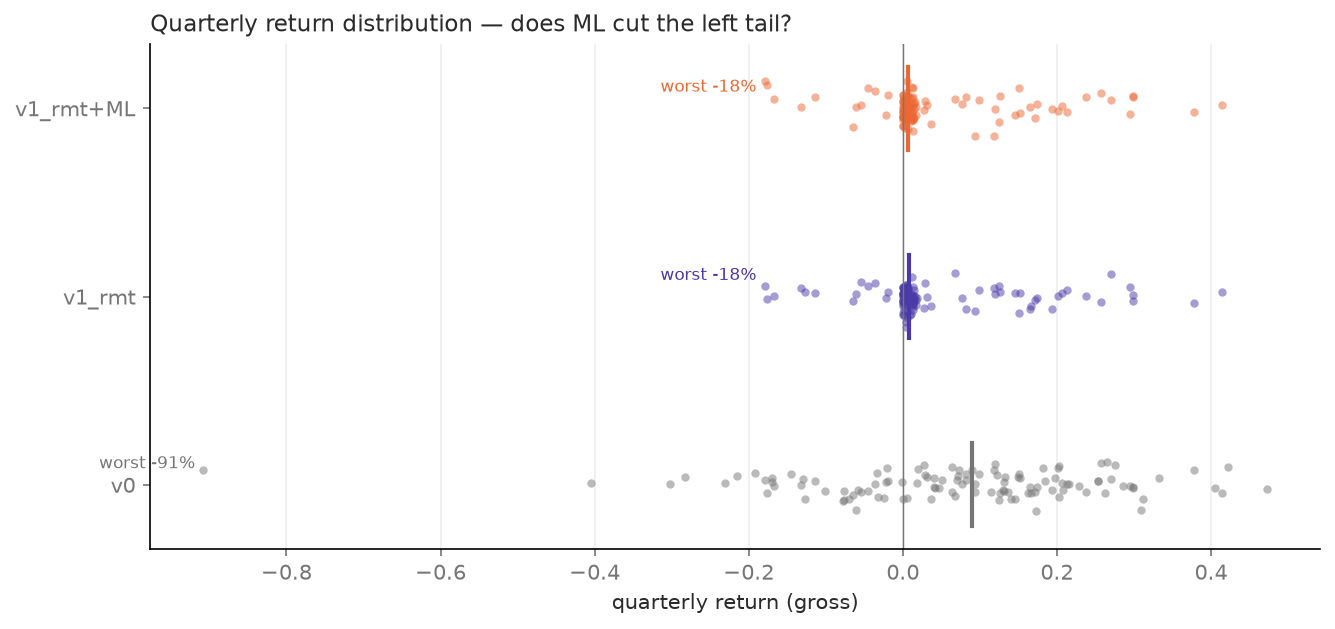

In [7]:
# FIG 6 — Quarterly return distribution per strategy (the tail cut)
dist = [("v0", "v0", COL["v0"]), ("v1rmt", "v1_rmt", COL["v1rmt"]), ("ml_Full", "v1_rmt+ML", COL["ml"])]
fig, ax = plt.subplots(figsize=(9, 4.3))
for i, (tag, lab, c) in enumerate(dist):
    q = pd.read_parquet(P / f"backtest_{tag}_gross_quarterly.parquet" if tag.startswith("ml")
                        else P / f"backtest_{tag}_quarterly.parquet")
    r = q["ret_q"].astype(float).to_numpy()
    x = np.random.default_rng(i).normal(i, 0.06, len(r))
    ax.scatter(r, x, s=16, color=c, alpha=0.5, lw=0)
    ax.plot([np.median(r)]*2, [i-0.22, i+0.22], color=c, lw=2)
    ax.annotate(f"worst {r.min():+.0%}", xy=(r.min(), i), xytext=(-4, 8), textcoords="offset points",
                ha="right", fontsize=8, color=c)
ax.axvline(0, color=MUTED, lw=0.7)
ax.set_yticks(range(3)); ax.set_yticklabels([d[1] for d in dist])
ax.set_xlabel("quarterly return (gross)", color=INK)
ax.set_title("Quarterly return distribution — does ML cut the left tail?",
             loc="left", fontsize=11, color=INK)
ax.tick_params(colors=MUTED); ax.grid(axis="y", alpha=0)
fig.tight_layout(); fig.savefig(FIG / "fig_return_dist.png", bbox_inches="tight"); plt.show()

In [8]:
# TABLES → CSV
show = tab[["trades", "n", "ret_q", "sharpe", "skew", "maxDD", "cumul", "worst_q"]].round(3)
show.to_csv(TAB / "table_ml_metrics.csv")

ct = pd.DataFrame({a: {**summary[a]["pred"], "n_veto": summary[a]["n_veto"],
                       "sharpe_net": tab.loc[f"ml_{a}_net", "sharpe"],
                       "maxDD_net": tab.loc[f"ml_{a}_net", "maxDD"]} for a in arms}).T.round(3)
ct.to_csv(TAB / "table_central_test.csv")

impdf = pd.DataFrame({a: summary[a]["importance"] for a in arms}).round(3)
impdf.to_csv(TAB / "table_feature_importance.csv")
print("tables written."); print(); print(show.to_string()); print(); print(ct.to_string())

tables written.

                     trades      n  ret_q  sharpe   skew  maxDD    cumul  worst_q
v0                    115.0  115.0  0.073   0.767 -1.291 -0.958  164.623   -0.908
v0_net                115.0  115.0  0.039   0.418 -1.332 -0.990    2.538   -0.946
v1                     58.0  115.0  0.043   0.558 -1.452 -0.959   12.988   -0.908
v1_net                 58.0  115.0  0.025   0.334 -1.939 -0.990    1.111   -0.946
v1rmt                  47.0  115.0  0.041   0.795  1.275 -0.517   58.170   -0.179
v1rmt_net              47.0  115.0  0.026   0.556  0.795 -0.585   12.398   -0.215
ml_A_vix_gross         40.0  115.0  0.037   0.737  1.506 -0.517   38.173   -0.179
ml_A_vix_net           40.0  115.0  0.024   0.514  0.977 -0.585    9.363   -0.215
ml_B_spectral_gross    44.0  115.0  0.040   0.802  1.378 -0.517   56.959   -0.179
ml_B_spectral_net      44.0  115.0  0.026   0.570  0.882 -0.585   12.782   -0.215
ml_Full_gross          44.0  115.0  0.040   0.802  1.378 -0.517   56.959   -0.179

## Reading (to fill in after execution, honestly)

- Does VIX+spectral beat VIX only (net Sharpe, skew, crisis recall)? by how much? significant
  given ~12 crises?
- Does the ML veto improve v1_rmt, or was the 252-day window already doing the work?
- Which features dominate the importance (VIX vs spectral)?
- Uncertainty: small sample → wide bars, cautious conclusions.